In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix


In [2]:
RNG_SEED = 42
np.random.seed(RNG_SEED)

In [3]:
# Load dataset from CSV & Train-Test Split
csv_path = "C://Users//amogh//OneDrive//Documents//MSBA//Predictive Analytics//HW1//bank+marketing//bank//bank-full.csv"
data = pd.read_csv(csv_path, sep=';')
feature_cols = ["age", "job", "marital", "education", "default", "balance", "housing", "loan", "contact", "day", "month"]
X_df = data[feature_cols].copy()
y = data["y"].to_numpy()
y_bin = np.where(y == "yes", 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_bin, test_size=0.20, stratify=y, random_state=RNG_SEED
)

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1675584704.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x="y", order=data["y"].value_counts().index, palette="Set2")


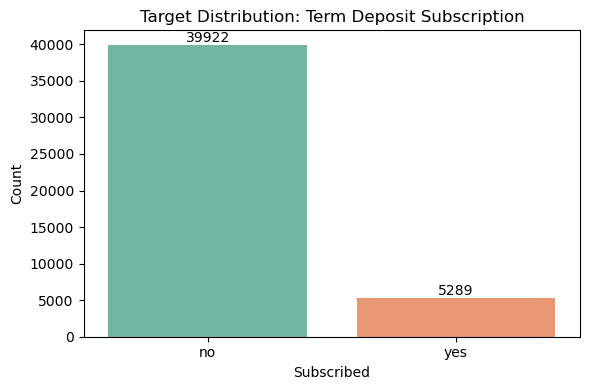

Target share:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Missing values:
No missing values found.


C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1675584704.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="y", y="age", ax=axes[0], palette="Set3")
C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1675584704.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="y", y="balance", ax=axes[1], palette="Set3")


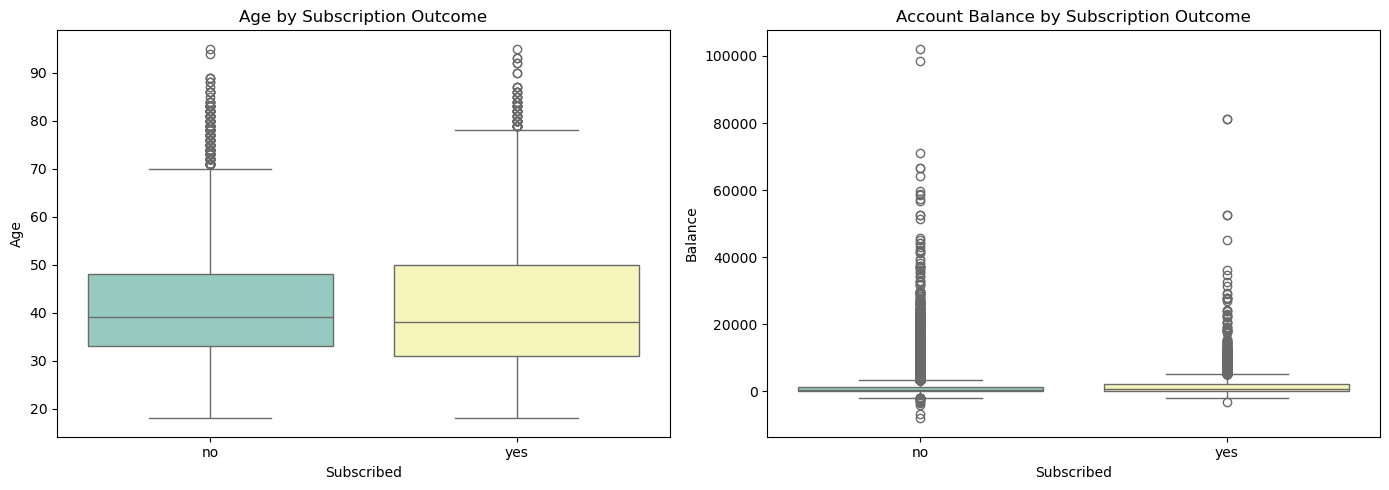

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1675584704.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="viridis")
C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1675584704.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="viridis")
C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1675584704.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="viridis")
C:\Users\amogh\AppData\Local\Temp\ipyker

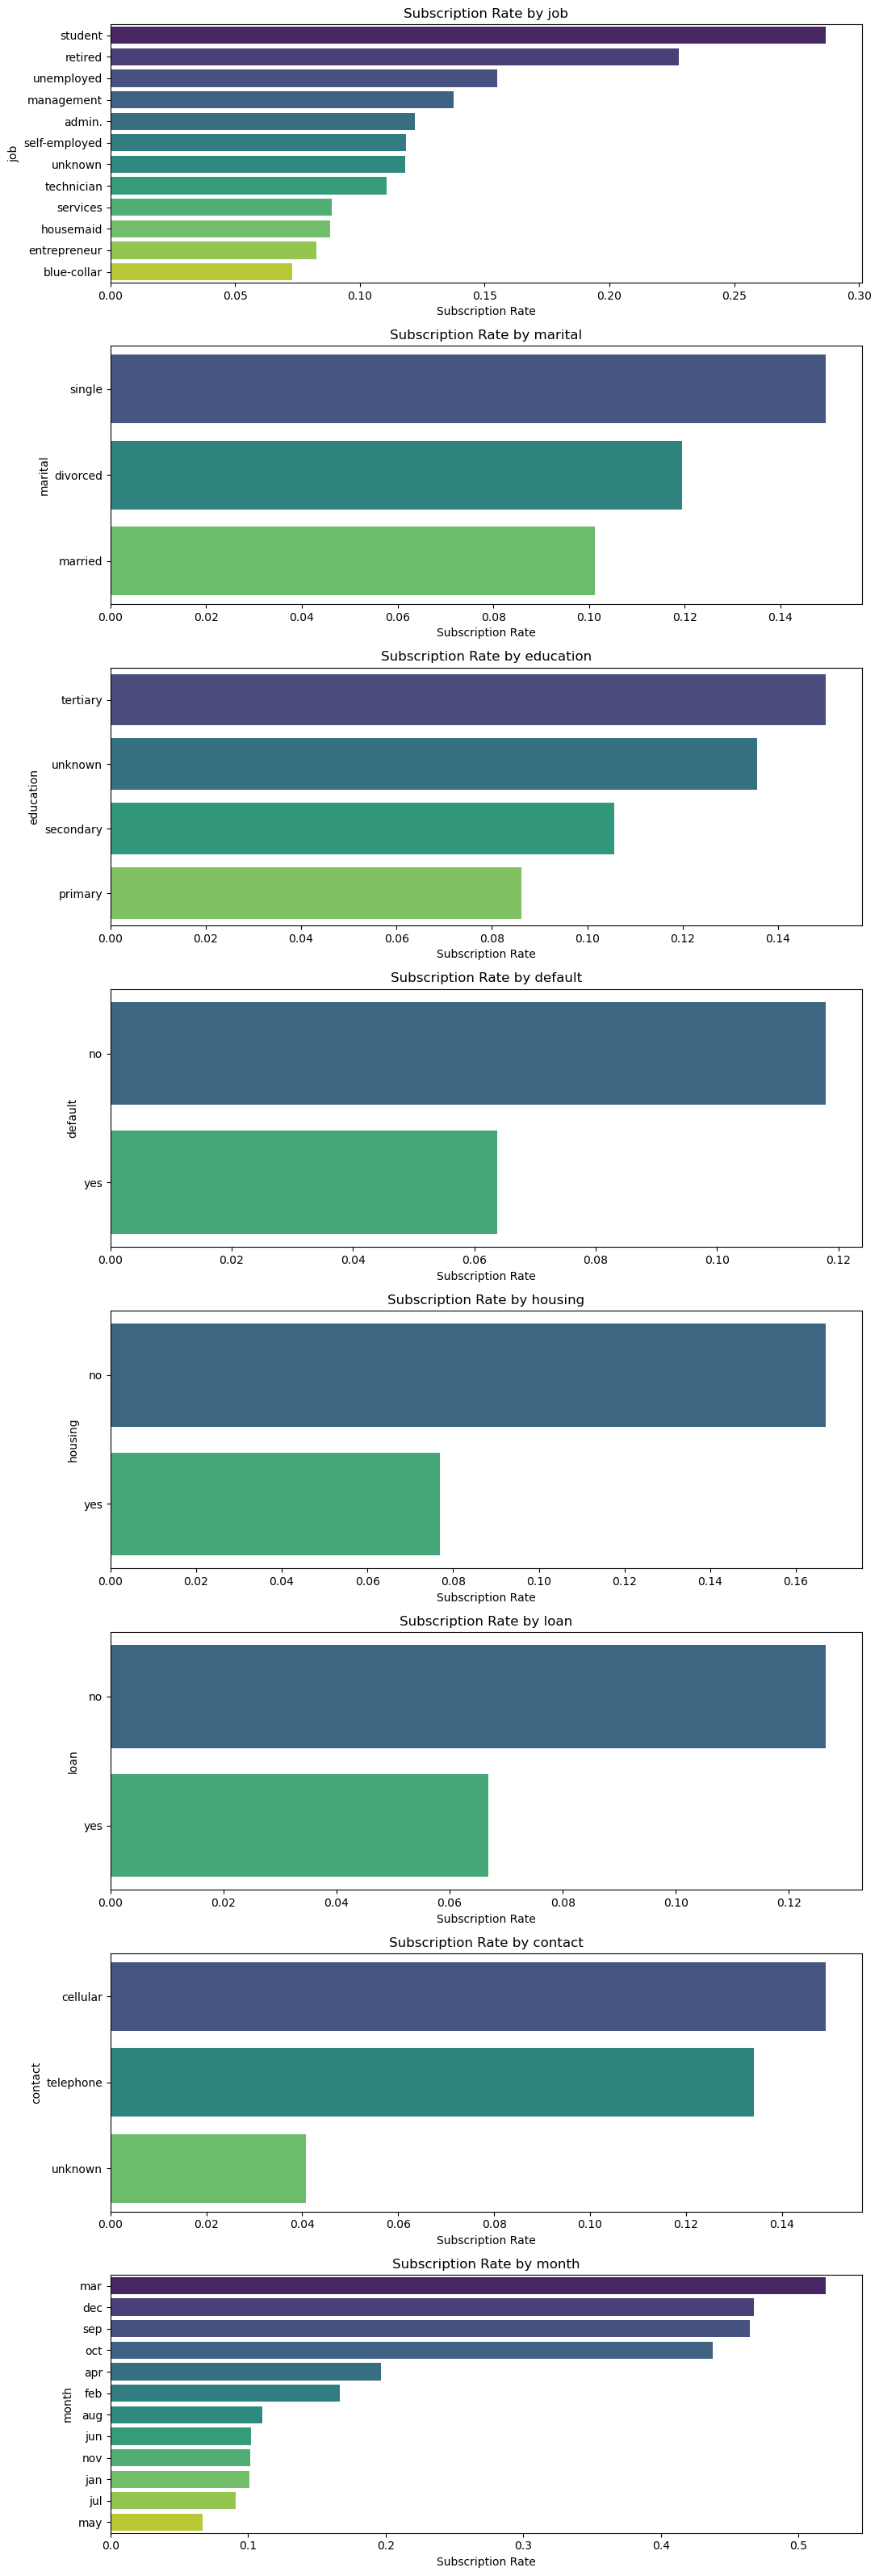

In [4]:
# Exploratory Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(data=data, x="y", order=data["y"].value_counts().index, palette="Set2")
plt.title("Target Distribution: Term Deposit Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Count")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.show()

print("Target share:")
print(data["y"].value_counts(normalize=True).round(4))

# Missing values
missing = data.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing values:")
print(missing if len(missing) > 0 else "No missing values found.")

# Age and balance by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=data, x="y", y="age", ax=axes[0], palette="Set3")
axes[0].set_title("Age by Subscription Outcome")
axes[0].set_xlabel("Subscribed")
axes[0].set_ylabel("Age")

sns.boxplot(data=data, x="y", y="balance", ax=axes[1], palette="Set3")
axes[1].set_title("Account Balance by Subscription Outcome")
axes[1].set_xlabel("Subscribed")
axes[1].set_ylabel("Balance")

plt.tight_layout()
plt.show()

# Subscription rate by key categorical variables
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month"]

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(11, 4 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    rate = data.groupby(col)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="viridis")
    ax.set_title(f"Subscription Rate by {col}")
    ax.set_xlabel("Subscription Rate")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [5]:
#Converting categorical variables to numerical using One-Hot-Encoding
ohe = pd.get_dummies(X_train, drop_first=True)
X_train = ohe.copy()

X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [6]:
#Standardizing numerical variables
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols]  = scaler.transform(X_test[numerical_cols])

In [7]:
# Stratified CV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

models = {}

In [8]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Logistic Regression Classifier
log_r = LogisticRegression(solver="liblinear", max_iter=1000)

# Logistic Regression Hyperparameter Grid
grid_log_reg = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 10]
}

# GridSearch CV set-up
gs_log_reg = GridSearchCV(log_r, grid_log_reg, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)

# Training on scaled data
gs_log_reg.fit(X_train_scaled, y_train)

# Best model
best_log_reg = gs_log_reg.best_estimator_
models["LogisticRegression"] = best_log_reg
print("Best params:", gs_log_reg.best_params_)
print("Best CV ROC-AUC:", gs_log_reg.best_score_)


Best params: {'C': 0.1, 'penalty': 'l2'}
Best CV ROC-AUC: 0.7382986937064565


In [9]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=RNG_SEED)

# Decision Tree Hyperparameter grid
grid_dt = {
    "max_depth": [None, 5, 7, 9, 12],
    "min_samples_leaf": [1, 5, 10, 20]
}

# GridSearchCV setup
gs_dt= GridSearchCV(dt_clf, grid_dt, scoring="roc_auc", cv=cv,n_jobs=-1, refit=True)

gs_dt.fit(X_train, y_train)

#Best Model 
best_dt = gs_dt.best_estimator_
models["DecisionTree"] = best_dt
print("Best params:", gs_dt.best_params_)
print("Best CV ROC-AUC:", gs_dt.best_score_)


Best params: {'max_depth': 12, 'min_samples_leaf': 20}
Best CV ROC-AUC: 0.7278302916282586


In [10]:
# K Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

#KNN Classifer
knn = KNeighborsClassifier()
grid_knn = {"n_neighbors": [3, 5, 7, 9, 11, 15], "weights": ["uniform", "distance"]}

# GridSearchCV setup
gs_knn = GridSearchCV(knn, grid_knn, scoring="roc_auc", refit=True, cv=cv)

# Training on scaled data
gs_knn.fit(X_train_scaled, y_train)

#Best Model
best_knn = gs_knn.best_estimator_
models["KNN"] = best_knn
print("Best params:", gs_knn.best_params_)
print("Best CV ROC-AUC:", gs_knn.best_score_)


C:\Users\amogh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\amogh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\amogh\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\amogh\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Best params: {'n_neighbors': 15, 'weights': 'distance'}
Best CV ROC-AUC: 0.7195841063893365


In [11]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=RNG_SEED, n_jobs=-1)

# Hyperparameter Grid
rf_grid = {
    "n_estimators": [20, 100],
    "max_depth": [12, 20],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt", "log2", None]
}

# GridSearchCV setup
gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_grid,
    scoring="roc_auc",
    refit=True,
    cv=cv,
    n_jobs=-1,
)
gs_rf.fit(X_train, y_train)

#Best Model
best_rf = gs_rf.best_estimator_
models["RandomForest"] = best_rf
print("Best params:", gs_rf.best_params_)
print("Best CV ROC-AUC:", gs_rf.best_score_)

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV ROC-AUC: 0.777507740998648


In [12]:
try:
    from xgboost import XGBClassifier  # type: ignore
    _XGB_OK = True
except Exception:
    try:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "--quiet"])
        from xgboost import XGBClassifier  # type: ignore
        _XGB_OK = True
        print("[Info] xgboost installed successfully.")
    except Exception as e:
        print(f"[Info] Could not install xgboost automatically: {e}")
        _XGB_OK = False

In [13]:
# XGBoost
if _XGB_OK:
    xgb = XGBClassifier(
        random_state=RNG_SEED,
        objective="binary:logistic",
        tree_method="hist",
        n_jobs=-1,
        eval_metric="logloss"
    )
# Hyperparameter Grid
    xgb_grid = {
        "n_estimators": [30, 100, 200],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1]
    }

# GridSearchCV setup
    gs_xgb = GridSearchCV(
        estimator=xgb,
        param_grid=xgb_grid,
        scoring="roc_auc",   # primary metric
        refit=True,
        cv=cv,
        n_jobs=-1,
    )
    gs_xgb.fit(X_train, y_train)

# Save best model
    best_xgb = gs_xgb.best_estimator_
    models["XGB"] = best_xgb
    print("Best params:", gs_xgb.best_params_)
    print("Best CV ROC-AUC:", gs_xgb.best_score_)

else:
    print("[Info] xgboost unavailable — skipping XGBoost Classifier.")

Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
Best CV ROC-AUC: 0.7816627998271084


In [14]:
# Evaluate all models
results = {}
pred_cache = {}
for name, est in models.items():
    if name in ["KNN", "LogisticRegression"]:
        X_test_used = X_test_scaled
    else:
        X_test_used = X_test
    # Predictions
    y_pred = est.predict(X_test_used)
    y_proba = est.predict_proba(X_test_used)[:, 1]

    pred_cache[name] = (y_pred, y_proba)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

# Summary Table
summary = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
print("\n[Test set performance] (higher is better)")
print(summary.round(4))

best_model_name = summary.index[0]
best_model = models[best_model_name]
print(f"\nBest model on Test by ROC-AUC: {best_model_name}")



[Test set performance] (higher is better)
                    Accuracy  Precision  Recall      F1  ROC-AUC
RandomForest          0.8853     0.5840  0.0690  0.1234   0.7928
XGB                   0.8857     0.5400  0.1531  0.2386   0.7925
LogisticRegression    0.8827     0.4906  0.0737  0.1282   0.7463
DecisionTree          0.8830     0.5000  0.1484  0.2289   0.7265
KNN                   0.8831     0.5022  0.1068  0.1761   0.7158

Best model on Test by ROC-AUC: RandomForest


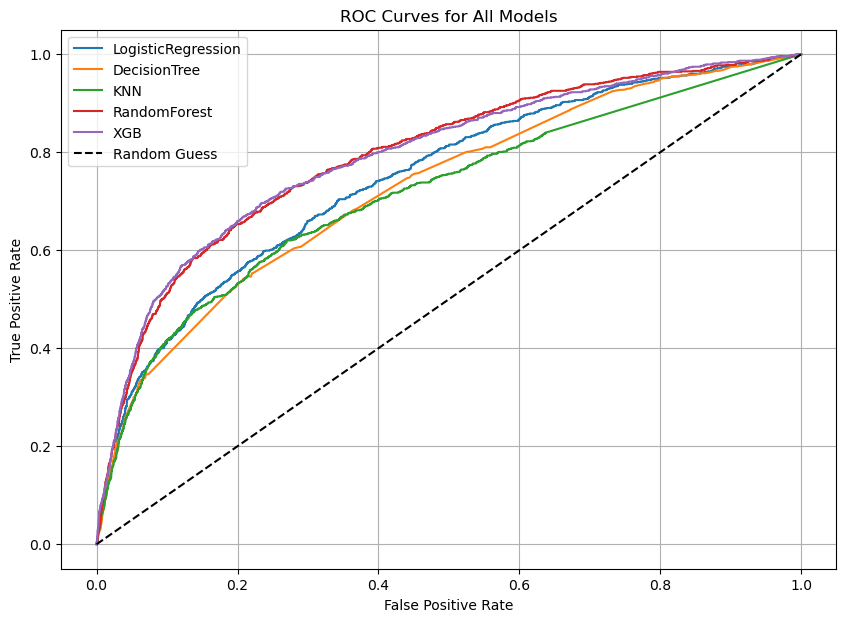

In [15]:
# ROC curves for all models
plt.figure(figsize=(10, 7))

for name, (y_pred, y_proba) in pred_cache.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True)
plt.show()

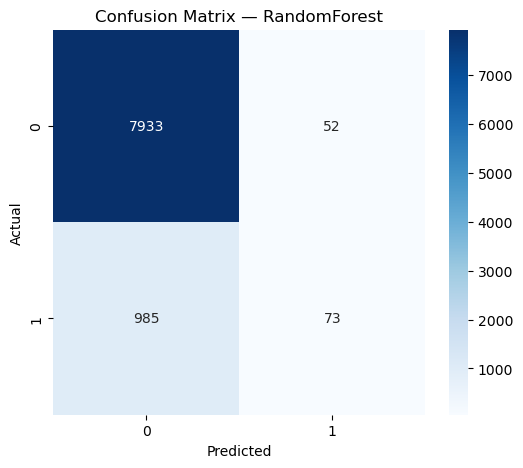

In [16]:
# Confusion Matrix for the Best Model
best_pred = pred_cache[best_model_name][0]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Best Overall Model: Random Forest
(Best params: max_depth=20, max_features='sqrt', min_samples_leaf=5, n_estimators=100)

Random Forest turned out to be the best model, with a test ROC‑AUC of 0.7928.

This means it was the most accurate at ranking positive cases higher than negative ones, which is especially important because only about 11% of the data belongs to the positive class.
The model performed well because:

- It aggregates many decision trees, so it reduces variance and becomes more stable.

- Using min_samples_leaf = 5 prevents the trees from memorizing noise in the training data.

- Using max_features = 'sqrt' makes each tree look at a different subset of features, which keeps the trees diverse.

- With 100 trees and max_depth = 20, the model captures complex patterns without becoming too noisy.

Overall, Random Forest strikes a good balance between flexibility and stability, which makes it better at generalization than the other models.


C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


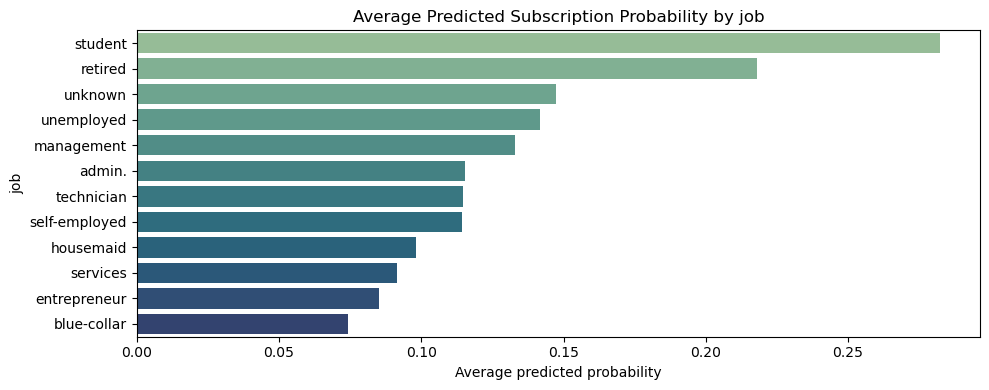

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


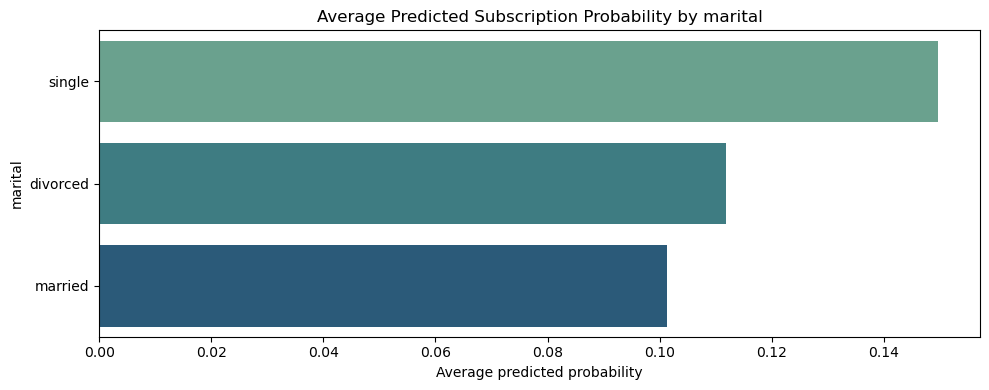

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


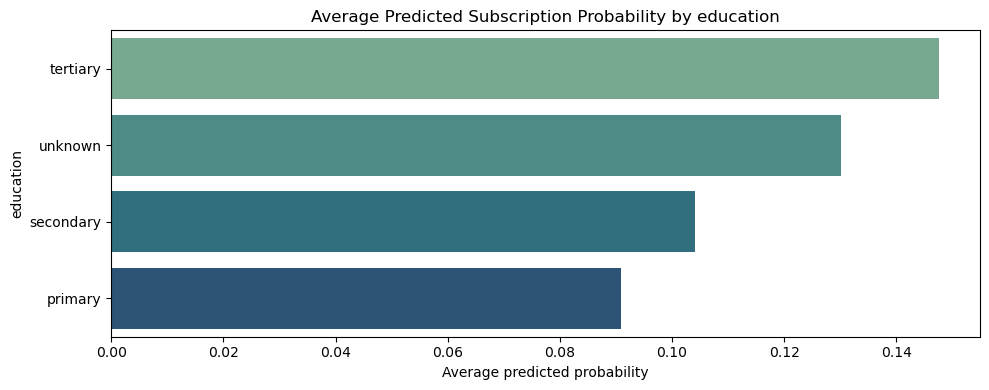

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


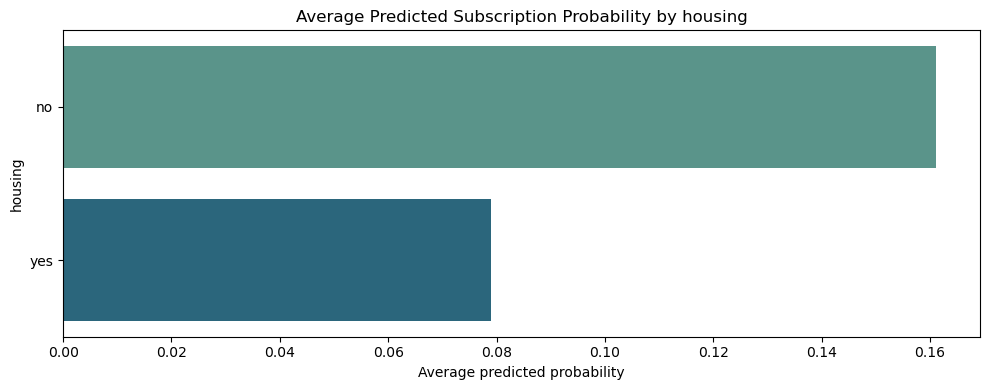

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


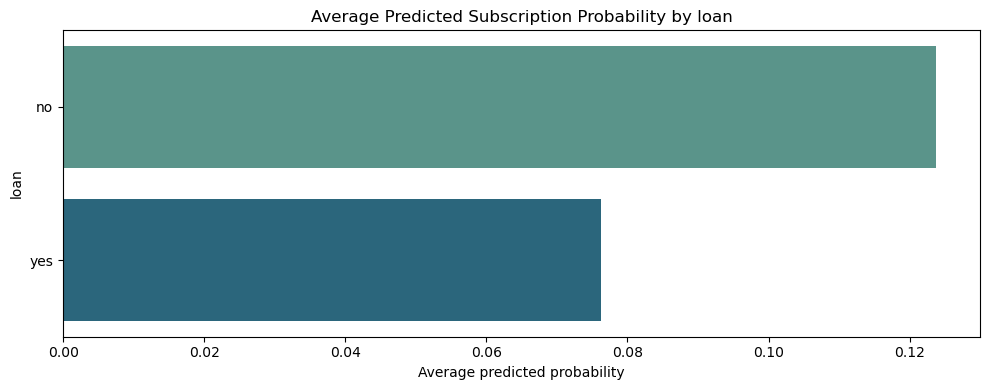

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


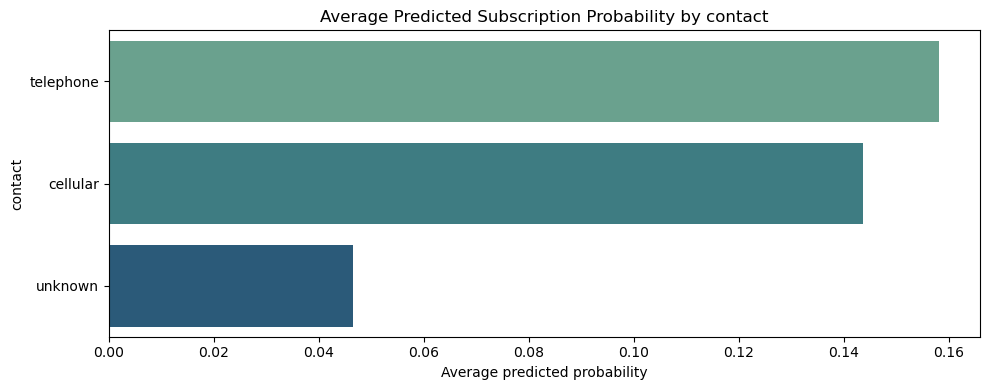

C:\Users\amogh\AppData\Local\Temp\ipykernel_38636\1120810165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.values, y=seg.index, palette="crest")


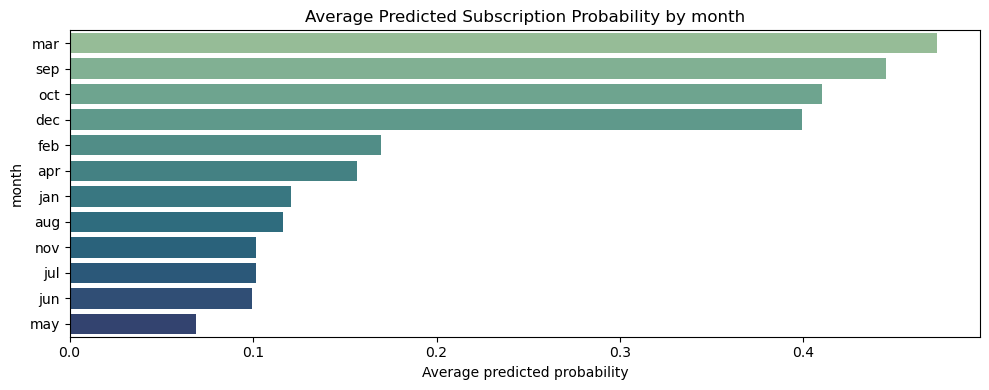

Top 20 highest-probability prospects:


,subscription_probability,age,balance,job,marital,education
44854,0.643889,55,7010,management,divorced,tertiary
31281,0.636497,44,483,management,single,tertiary
43102,0.631515,23,381,student,single,secondary
31318,0.627459,43,2987,management,married,tertiary
44722,0.627039,43,2251,management,divorced,tertiary
41930,0.619040,19,329,student,single,secondary
44819,0.616162,58,2986,management,divorced,unknown
41606,0.606211,25,808,management,single,tertiary
45098,0.604127,44,11115,technician,single,unknown
41575,0.603599,40,4775,admin.,married,secondary



Business Lift Table:


,Top % of ranked customers,Response rate in top group,Overall response rate,Lift
0,Top 10%,0.4679,0.117,4.00
1,Top 20%,0.3457,0.117,2.95
2,Top 30%,0.2714,0.117,2.32
3,Top 40%,0.2262,0.117,1.93


In [29]:
# Business Post Hoc Analysis

feature_cols = ["age", "job", "marital", "education", "default", "balance", "housing", "loan", "contact", "day", "month"]
test_data = data[feature_cols + ["y"]].iloc[X_test.index].copy()

test_data["actual_subscription"] = y_test
test_data["predicted_subscription"] = pred_cache[best_model_name][0]
test_data["subscription_probability"] = pred_cache[best_model_name][1]
test_data["correct_prediction"] = test_data["actual_subscription"] == test_data["predicted_subscription"]
test_data["actual_label"] = np.where(test_data["actual_subscription"] == 1, "yes", "no")
test_data["predicted_label"] = np.where(test_data["predicted_subscription"] == 1, "yes", "no")

# Predicted response rate by segment
segment_cols = ["job", "marital", "education", "housing", "loan", "contact", "month"]
for col in segment_cols:
    if col in test_data.columns:
        seg = test_data.groupby(col)["subscription_probability"].mean().sort_values(ascending=False)
        plt.figure(figsize=(10, 4))
        sns.barplot(x=seg.values, y=seg.index, palette="crest")
        plt.title(f"Average Predicted Subscription Probability by {col}")
        plt.xlabel("Average predicted probability")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

# High-probability customer profile
top_customers = test_data.sort_values("subscription_probability", ascending=False).head(20)
display_cols = ["subscription_probability", "age", "balance", "job", "marital", "education"]
print("Top 20 highest-probability prospects:")
display(top_customers[display_cols])

# Business lift table
lift_cutoffs = [0.1, 0.2, 0.3, 0.4]
lift_rows = []
overall_rate = test_data["actual_subscription"].mean()

for q in lift_cutoffs:
    n = int(len(test_data) * q)
    top_slice = test_data.sort_values("subscription_probability", ascending=False).head(n)
    top_rate = top_slice["actual_subscription"].mean()
    lift_rows.append({
        "Top % of ranked customers": f"Top {int(q*100)}%",
        "Response rate in top group": round(top_rate, 4),
        "Overall response rate": round(overall_rate, 4),
        "Lift": round(top_rate / overall_rate, 2)
    })

lift_df = pd.DataFrame(lift_rows)
print("\nBusiness Lift Table:")
display(lift_df)